In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import pandas_ta as ta  # từ pandas-ta-openbb
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"pandas-ta version: {ta.version}")

Using device: cpu
pandas-ta version: 0.4.23


In [2]:
DATA_DIR = r"D:\S2_Year4\Quantitative Trading\Project\data"

VN30_SYMBOLS = [
    'ACB', 'BCM', 'BID', 'BVH', 'CTG', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG',
    'MBB', 'MSN', 'MWG', 'NVL', 'PDR', 'PLX', 'POW', 'SAB', 'SSI', 'STB',
    'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE'
]

In [3]:
def load_all_stocks(data_dir, symbols):
    """Đọc tất cả file CSV và gộp thành 1 DataFrame."""
    all_dfs = []
    loaded = []
    
    for symbol in symbols:
        filepath = os.path.join(data_dir, f"{symbol}.csv")
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            all_dfs.append(df)
            loaded.append(symbol)
        else:
            print(f"⚠️ Không tìm thấy: {filepath}")
    
    if not all_dfs:
        raise FileNotFoundError(f"Không tìm thấy file CSV nào trong {data_dir}")
    
    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"Đã load {len(loaded)}/{len(symbols)} mã")
    print(f"Tổng số dòng: {len(combined):,}")
    return combined

df_raw = load_all_stocks(DATA_DIR, VN30_SYMBOLS)

Đã load 30/30 mã
Tổng số dòng: 63,397


In [4]:
df = df_raw.copy()
df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
df = df.sort_values(['Symbol', 'TradingDate']).reset_index(drop=True)
df = df.drop(columns=['Time', 'Value'], errors='ignore')

print(f"Shape: {df.shape}")
print(f"Thời gian: {df['TradingDate'].min().date()} → {df['TradingDate'].max().date()}")
print(f"Số mã: {df['Symbol'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (63397, 7)
Thời gian: 2013-01-02 → 2023-06-30
Số mã: 30

Missing values:
Symbol         0
TradingDate    0
Open           0
High           0
Low            0
Close          0
Volume         0
dtype: int64


,Symbol,TradingDate,Open,High,Low,Close,Volume
0,ACB,2013-01-02,16300,17400,16300,17300,2578600
1,ACB,2013-01-03,17500,17800,16700,17000,1967200
2,ACB,2013-01-04,16900,17200,16700,17200,1170100
3,ACB,2013-01-07,17000,17500,17000,17200,1355700
4,ACB,2013-01-08,17100,17500,16900,17300,2180000


In [5]:
def create_features(group):
    """
    Tạo ~50 technical indicators cho mỗi cổ phiếu.
    Sử dụng thư viện pandas-ta-openbb.
    """
    df = group.copy().reset_index(drop=True)
    
    # Ép kiểu float để tránh lỗi numba với NaN
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = df[col].astype(float)
    
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    open_price = df['Open']
    
    # ========== MOMENTUM (Returns) ==========
    for p in [1, 3, 5, 10, 20, 60]:
        df[f'return_{p}d'] = close.pct_change(p)
    
    for p in [5, 10, 20]:
        df[f'roc_{p}'] = ta.roc(close, length=p)
    
    # ========== TREND ==========
    for p in [5, 10, 20, 50]:
        sma = ta.sma(close, length=p)
        df[f'close_to_sma_{p}'] = close / sma
    
    # MACD
    macd_df = ta.macd(close, fast=12, slow=26, signal=9)
    if macd_df is not None:
        df['macd'] = macd_df.iloc[:, 0]
        df['macd_hist'] = macd_df.iloc[:, 1]
        df['macd_signal'] = macd_df.iloc[:, 2]
    
    # ========== OSCILLATOR ==========
    df['rsi_14'] = ta.rsi(close, length=14)
    df['rsi_7'] = ta.rsi(close, length=7)
    
    stoch_df = ta.stoch(high, low, close, k=14, d=3)
    if stoch_df is not None:
        df['stoch_k'] = stoch_df.iloc[:, 0]
        df['stoch_d'] = stoch_df.iloc[:, 1]
    
    df['willr_14'] = ta.willr(high, low, close, length=14)
    df['cci_20'] = ta.cci(high, low, close, length=20)
    
    # ========== VOLATILITY ==========
    atr = ta.atr(high, low, close, length=14)
    df['atr_ratio'] = atr / close
    
    bb_df = ta.bbands(close, length=20, std=2)
    if bb_df is not None:
        bb_lower = bb_df.iloc[:, 0]
        bb_mid = bb_df.iloc[:, 1]
        bb_upper = bb_df.iloc[:, 2]
        df['bb_pct_b'] = (close - bb_lower) / (bb_upper - bb_lower)
        df['bb_width'] = (bb_upper - bb_lower) / bb_mid
    
    df['std_ratio'] = close.rolling(20).std() / close
    
    # ========== VOLUME ==========
    vol_sma_5 = ta.sma(volume, length=5)
    vol_sma_20 = ta.sma(volume, length=20)
    df['vol_ratio_5_20'] = vol_sma_5 / vol_sma_20
    df['vol_change_1d'] = volume.pct_change(1)
    df['vol_change_5d'] = volume.pct_change(5)
    
    obv = ta.obv(close, volume)
    if obv is not None:
        df['obv_norm'] = obv / vol_sma_20
    
    # ========== PRICE PATTERN ==========
    df['hl_ratio'] = (high - low) / close
    df['co_ratio'] = (close - open_price) / open_price
    df['gap'] = (open_price - close.shift(1)) / close.shift(1)
    df['upper_shadow'] = (high - np.maximum(close, open_price)) / close
    df['lower_shadow'] = (np.minimum(close, open_price) - low) / close
    
    return df

print("🔧 Đang tạo features...")
df_featured = df.groupby('Symbol', group_keys=False).apply(create_features)

feature_cols = [c for c in df_featured.columns 
                if c not in ['Symbol', 'TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume']]
print(f"Shape: {df_featured.shape}")
print(f"Số features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

🔧 Đang tạo features...
Shape: (63397, 42)
Số features: 35
Features: ['return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_20d', 'return_60d', 'roc_5', 'roc_10', 'roc_20', 'close_to_sma_5', 'close_to_sma_10', 'close_to_sma_20', 'close_to_sma_50', 'macd', 'macd_hist', 'macd_signal', 'rsi_14', 'rsi_7', 'stoch_k', 'stoch_d', 'willr_14', 'cci_20', 'atr_ratio', 'bb_pct_b', 'bb_width', 'std_ratio', 'vol_ratio_5_20', 'vol_change_1d', 'vol_change_5d', 'obv_norm', 'hl_ratio', 'co_ratio', 'gap', 'upper_shadow', 'lower_shadow']


Shape trước dropna: (63397, 43)
Shape sau dropna:   (61134, 43)
Thời gian: 2013-04-01 → 2023-06-23

Target statistics:
count    61134.000000
mean         0.001346
std          0.051885
min         -1.000000
25%         -0.021641
50%          0.000000
75%          0.026042
max          0.387500
Name: target, dtype: float64


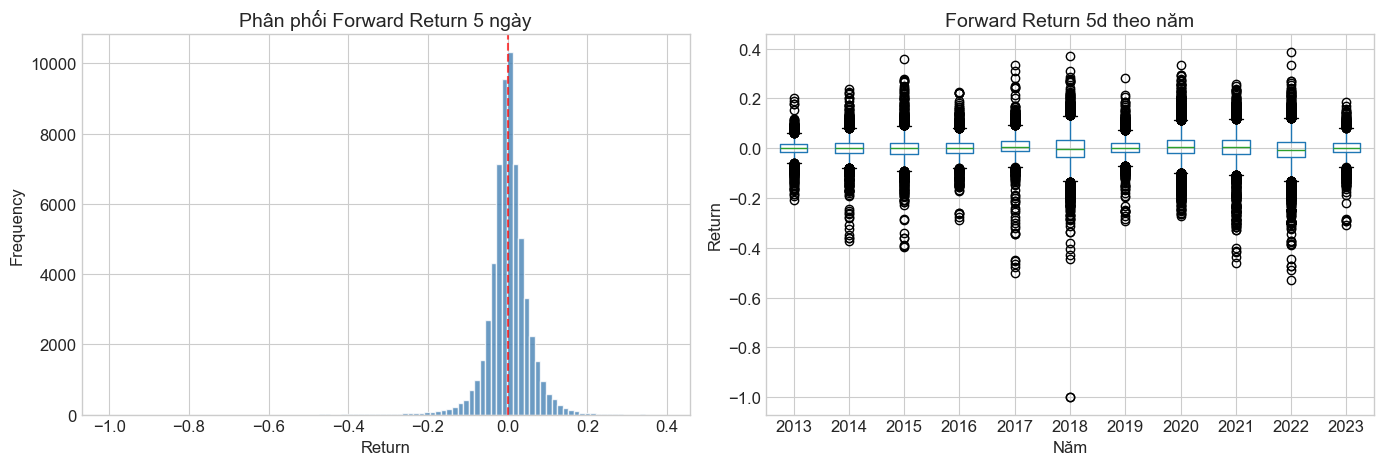

In [6]:
FORWARD_DAYS = 5

df_featured['target'] = df_featured.groupby('Symbol')['Close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1
)

# ⚠️ Thay thế tất cả inf thành NaN, rồi dropna 1 lần
df_featured = df_featured.replace([np.inf, -np.inf], np.nan)

print(f"Shape trước dropna: {df_featured.shape}")
df_clean = df_featured.dropna().reset_index(drop=True)
print(f"Shape sau dropna:   {df_clean.shape}")
print(f"Thời gian: {df_clean['TradingDate'].min().date()} → {df_clean['TradingDate'].max().date()}")
print(f"\nTarget statistics:\n{df_clean['target'].describe()}")

# Vẽ phân phối target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['target'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Phân phối Forward Return {FORWARD_DAYS} ngày', fontsize=14)
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

df_clean['Year'] = df_clean['TradingDate'].dt.year
df_clean.boxplot(column='target', by='Year', ax=axes[1])
axes[1].set_title(f'Forward Return {FORWARD_DAYS}d theo năm', fontsize=14)
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Return')
plt.suptitle('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
TRAIN_END = '2020-12-31'
VAL_END = '2022-06-30'

df_train = df_clean[df_clean['TradingDate'] <= TRAIN_END]
df_val = df_clean[(df_clean['TradingDate'] > TRAIN_END) & (df_clean['TradingDate'] <= VAL_END)]
df_test = df_clean[df_clean['TradingDate'] > VAL_END]

print(f"Train: {len(df_train):>6,} samples | {df_train['TradingDate'].min().date()} → {df_train['TradingDate'].max().date()}")
print(f"Val:   {len(df_val):>6,} samples | {df_val['TradingDate'].min().date()} → {df_val['TradingDate'].max().date()}")
print(f"Test:  {len(df_test):>6,} samples | {df_test['TradingDate'].min().date()} → {df_test['TradingDate'].max().date()}")

Train: 42,024 samples | 2013-04-01 → 2020-12-31
Val:   11,490 samples | 2021-01-04 → 2022-06-30
Test:   7,620 samples | 2022-07-01 → 2023-06-23


In [8]:
# Chuẩn bị features
FEATURE_COLS = [c for c in df_clean.columns 
                if c not in ['Symbol', 'TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'Year']]

print(f"Số features: {len(FEATURE_COLS)}")

X_train, y_train = df_train[FEATURE_COLS].values, df_train['target'].values
X_val, y_val = df_val[FEATURE_COLS].values, df_val['target'].values
X_test, y_test = df_test[FEATURE_COLS].values, df_test['target'].values

Số features: 35


In [9]:
# StandardScaler: fit trên Train, transform lên Val/Test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Xử lý inf/nan
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Chuyển sang PyTorch Tensor
def to_tensor(X, y):
    return (torch.FloatTensor(X).to(device), 
            torch.FloatTensor(y).reshape(-1, 1).to(device))

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_test_t, y_test_t = to_tensor(X_test, y_test)

In [10]:
BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print(f"\nX_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Device: {device}")


X_train: (42024, 35) | X_val: (11490, 35) | X_test: (7620, 35)
Device: cpu


In [11]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron: Input → 128 → 64 → 32 → 1
    Hỗ trợ tính L1 loss và Sparsity Ratio.
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def get_l1_loss(self):
        """Tổng |weights| của tất cả layers."""
        return sum(torch.sum(torch.abs(p)) for p in self.parameters())
    
    def get_sparsity_ratio(self, threshold=1e-4):
        """Tỉ lệ weights ≈ 0."""
        total = sum(p.numel() for p in self.parameters())
        near_zero = sum((p.abs() < threshold).sum().item() for p in self.parameters())
        return near_zero / total if total > 0 else 0

input_dim = len(FEATURE_COLS)
print(f"Architecture: {input_dim} → 128 → 64 → 32 → 1")
print(f"Total params: {sum(p.numel() for p in MLP(input_dim).parameters()):,}")

Architecture: 35 → 128 → 64 → 32 → 1
Total params: 15,425


In [12]:
def train_model(model, train_loader, X_val_t, y_val_t, 
                epochs=200, lr=0.001, l1_lambda=0.0, 
                patience=20, model_name="Model"):
    """
    Huấn luyện MLP với early stopping.
    l1_lambda=0 → Dense MLP | l1_lambda>0 → Sparse MLP
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None
    no_improve = 0
    
    print(f"\n{'='*60}")
    print(f"🚀 {model_name} | L1 λ = {l1_lambda}")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0
        n_batches = 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_b)
            mse_loss = criterion(y_pred, y_b)
            total_loss = mse_loss + l1_lambda * model.get_l1_loss() if l1_lambda > 0 else mse_loss
            total_loss.backward()
            optimizer.step()
            epoch_loss += mse_loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # --- Validation ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)
        
        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            sp = model.get_sparsity_ratio() if l1_lambda > 0 else 0
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f} | Sparsity: {sp:.1%}")
        
        if no_improve >= patience:
            print(f"  ⏹️ Early stop at epoch {epoch+1} (best: {best_epoch+1})")
            break
    
    model.load_state_dict(best_state)
    print(f"  Best epoch: {best_epoch+1} | Val MSE: {best_val_loss:.6f}")
    return model, train_losses, val_losses

In [13]:
dense_model = MLP(input_dim).to(device)
dense_model, dense_train_losses, dense_val_losses = train_model(
    dense_model, train_loader, X_val_t, y_val_t,
    epochs=200, lr=0.001, l1_lambda=0.0, patience=20,
    model_name="Dense MLP (Baseline)"
)


🚀 Dense MLP (Baseline) | L1 λ = 0.0
  Epoch   1/200 | Train: 0.057774 | Val: 0.005946 | Sparsity: 0.0%
  Epoch  20/200 | Train: 0.002423 | Val: 0.003435 | Sparsity: 0.0%
  ⏹️ Early stop at epoch 28 (best: 8)
  Best epoch: 8 | Val MSE: 0.003398


In [14]:
L1_LAMBDAS = [1e-5, 1e-4, 1e-3]
lambda_results = {}

for lam in L1_LAMBDAS:
    m = MLP(input_dim).to(device)
    m, _, _ = train_model(m, train_loader, X_val_t, y_val_t,
                          epochs=200, lr=0.001, l1_lambda=lam, patience=20,
                          model_name=f"Sparse MLP (λ={lam})")
    m.eval()
    with torch.no_grad():
        val_mse = nn.MSELoss()(m(X_val_t), y_val_t).item()
    lambda_results[lam] = {'val_mse': val_mse, 'sparsity': m.get_sparsity_ratio()}
    print(f"  → Val MSE: {val_mse:.6f} | Sparsity: {m.get_sparsity_ratio():.1%}")

best_lambda = min(lambda_results, key=lambda k: lambda_results[k]['val_mse'])
print(f"\n🏆 Best λ = {best_lambda} | Val MSE = {lambda_results[best_lambda]['val_mse']:.6f}")


🚀 Sparse MLP (λ=1e-05) | L1 λ = 1e-05
  Epoch   1/200 | Train: 0.056916 | Val: 0.005648 | Sparsity: 0.1%
  Epoch  20/200 | Train: 0.002421 | Val: 0.003438 | Sparsity: 29.9%
  ⏹️ Early stop at epoch 30 (best: 10)
  Best epoch: 10 | Val MSE: 0.003411
  → Val MSE: 0.003411 | Sparsity: 10.2%

🚀 Sparse MLP (λ=0.0001) | L1 λ = 0.0001
  Epoch   1/200 | Train: 0.032331 | Val: 0.004250 | Sparsity: 1.4%
  Epoch  20/200 | Train: 0.002418 | Val: 0.003405 | Sparsity: 89.5%
  ⏹️ Early stop at epoch 31 (best: 11)
  Best epoch: 11 | Val MSE: 0.003383
  → Val MSE: 0.003383 | Sparsity: 63.8%

🚀 Sparse MLP (λ=0.001) | L1 λ = 0.001
  Epoch   1/200 | Train: 0.044219 | Val: 0.004996 | Sparsity: 9.1%
  Epoch  20/200 | Train: 0.002411 | Val: 0.003408 | Sparsity: 60.5%
  Epoch  40/200 | Train: 0.002424 | Val: 0.003402 | Sparsity: 56.2%
  ⏹️ Early stop at epoch 45 (best: 25)
  Best epoch: 25 | Val MSE: 0.003400
  → Val MSE: 0.003400 | Sparsity: 58.1%

🏆 Best λ = 0.0001 | Val MSE = 0.003383


In [15]:
sparse_model = MLP(input_dim).to(device)
sparse_model, sparse_train_losses, sparse_val_losses = train_model(
    sparse_model, train_loader, X_val_t, y_val_t,
    epochs=200, lr=0.001, l1_lambda=best_lambda, patience=20,
    model_name=f"Sparse MLP (λ={best_lambda})"
)


🚀 Sparse MLP (λ=0.0001) | L1 λ = 0.0001
  Epoch   1/200 | Train: 0.037792 | Val: 0.004698 | Sparsity: 1.3%
  Epoch  20/200 | Train: 0.002416 | Val: 0.003427 | Sparsity: 91.9%
  Epoch  40/200 | Train: 0.002418 | Val: 0.003409 | Sparsity: 62.9%
  Epoch  60/200 | Train: 0.002418 | Val: 0.003403 | Sparsity: 57.1%
  ⏹️ Early stop at epoch 66 (best: 46)
  Best epoch: 46 | Val MSE: 0.003400


In [16]:
def evaluate_model(model, X_t, y_t, y_np, name="Model"):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_t).cpu().numpy().flatten()
    
    mse = mean_squared_error(y_np, y_pred)
    rmse = np.sqrt(mse)
    ic = np.corrcoef(y_np, y_pred)[0, 1]
    sparsity = model.get_sparsity_ratio()
    
    print(f"\n📊 {name}:")
    print(f"  MSE:      {mse:.6f}")
    print(f"  RMSE:     {rmse:.6f}")  
    print(f"  IC:       {ic:.4f}")
    print(f"  Sparsity: {sparsity:.1%}")
    
    return {'name': name, 'mse': mse, 'rmse': rmse, 'ic': ic, 
            'sparsity': sparsity, 'y_pred': y_pred, 'y_true': y_np}

dense_res = evaluate_model(dense_model, X_test_t, y_test_t, y_test, "Dense MLP")
sparse_res = evaluate_model(sparse_model, X_test_t, y_test_t, y_test, "Sparse MLP")


📊 Dense MLP:
  MSE:      0.003143
  RMSE:     0.056059
  IC:       0.0528
  Sparsity: 0.1%

📊 Sparse MLP:
  MSE:      0.003141
  RMSE:     0.056042
  IC:       nan
  Sparsity: 59.5%


In [17]:
print("\n" + "=" * 55)
print("         BẢNG SO SÁNH KẾT QUẢ (TEST SET)")
print("=" * 55)
print(f"{'Metric':<18} {'Dense MLP':>15} {'Sparse MLP':>15}")
print("-" * 55)
print(f"{'MSE':<18} {dense_res['mse']:>15.6f} {sparse_res['mse']:>15.6f}")
print(f"{'RMSE':<18} {dense_res['rmse']:>15.6f} {sparse_res['rmse']:>15.6f}")
print(f"{'IC':<18} {dense_res['ic']:>15.4f} {sparse_res['ic']:>15.4f}")
print(f"{'Sparsity Ratio':<18} {dense_res['sparsity']:>14.1%} {sparse_res['sparsity']:>14.1%}")
print("=" * 55)


         BẢNG SO SÁNH KẾT QUẢ (TEST SET)
Metric                   Dense MLP      Sparse MLP
-------------------------------------------------------
MSE                       0.003143        0.003141
RMSE                      0.056059        0.056042
IC                          0.0528             nan
Sparsity Ratio               0.1%          59.5%


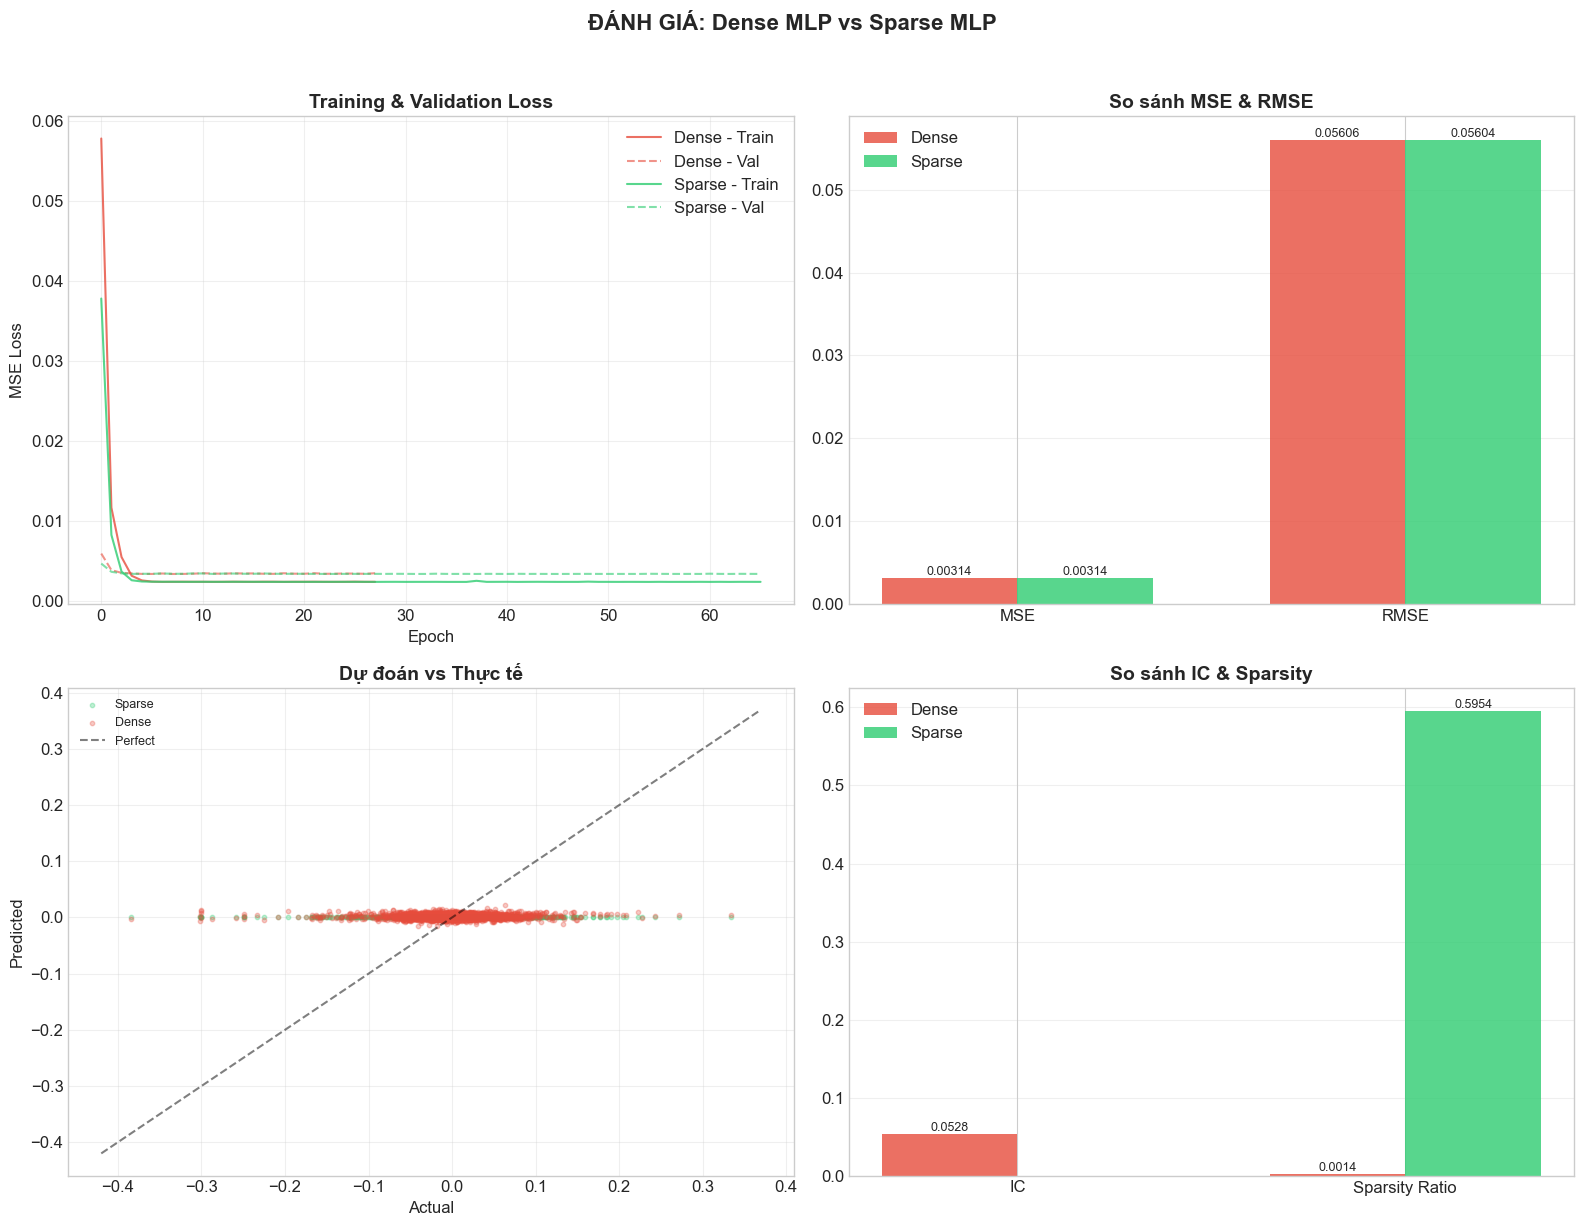

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training Loss Curve
ax = axes[0, 0]
ax.plot(dense_train_losses, label='Dense - Train', color='#E74C3C', alpha=0.8)
ax.plot(dense_val_losses, label='Dense - Val', color='#E74C3C', ls='--', alpha=0.6)
ax.plot(sparse_train_losses, label='Sparse - Train', color='#2ECC71', alpha=0.8)
ax.plot(sparse_val_losses, label='Sparse - Val', color='#2ECC71', ls='--', alpha=0.6)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. MSE & RMSE Bar Chart
ax = axes[0, 1]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [dense_res['mse'], dense_res['rmse']], w, label='Dense', color='#E74C3C', alpha=0.8)
b2 = ax.bar(x + w/2, [sparse_res['mse'], sparse_res['rmse']], w, label='Sparse', color='#2ECC71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['MSE', 'RMSE'])
ax.set_title('So sánh MSE & RMSE', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.5f}', ha='center', va='bottom', fontsize=9)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.5f}', ha='center', va='bottom', fontsize=9)

# 3. Scatter: Predicted vs Actual
ax = axes[1, 0]
idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
ax.scatter(sparse_res['y_true'][idx], sparse_res['y_pred'][idx], alpha=0.3, s=10, c='#2ECC71', label='Sparse')
ax.scatter(dense_res['y_true'][idx], dense_res['y_pred'][idx], alpha=0.3, s=10, c='#E74C3C', label='Dense')
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
ax.set_title('Dự đoán vs Thực tế', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4. IC & Sparsity
ax = axes[1, 1]
b1 = ax.bar(x - w/2, [dense_res['ic'], dense_res['sparsity']], w, label='Dense', color='#E74C3C', alpha=0.8)
b2 = ax.bar(x + w/2, [sparse_res['ic'], sparse_res['sparsity']], w, label='Sparse', color='#2ECC71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['IC', 'Sparsity Ratio'])
ax.set_title('So sánh IC & Sparsity', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ĐÁNH GIÁ: Dense MLP vs Sparse MLP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
def get_feature_importance(model, feature_names):
    """Feature importance = tổng |weights| từ input layer."""
    for module in model.network:
        if isinstance(module, nn.Linear):
            weights = module.weight.data.cpu().numpy()
            break
    importance = np.sum(np.abs(weights), axis=0)
    fi = pd.DataFrame({'feature': feature_names, 'importance': importance})
    return fi.sort_values('importance', ascending=False).reset_index(drop=True), weights

dense_fi, dense_w = get_feature_importance(dense_model, FEATURE_COLS)
sparse_fi, sparse_w = get_feature_importance(sparse_model, FEATURE_COLS)

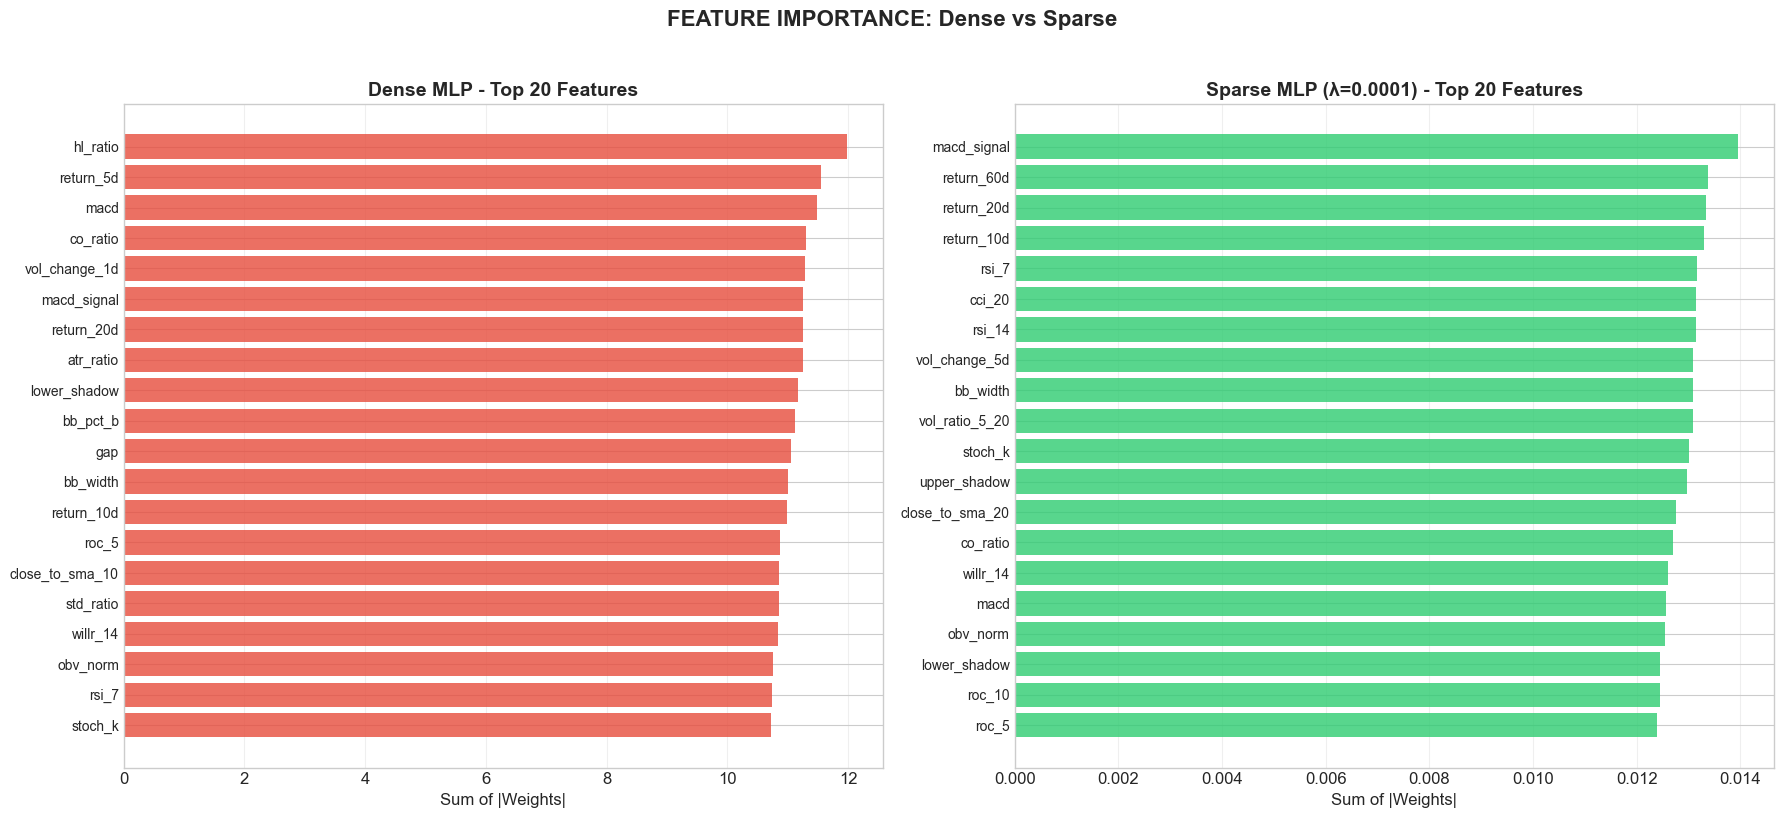

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_n = 20

for ax, fi, title, color in [
    (axes[0], dense_fi, 'Dense MLP', '#E74C3C'),
    (axes[1], sparse_fi, f'Sparse MLP (λ={best_lambda})', '#2ECC71')
]:
    top = fi.head(top_n)
    ax.barh(range(top_n), top['importance'].values, color=color, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top['feature'].values, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'{title} - Top {top_n} Features', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sum of |Weights|')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('FEATURE IMPORTANCE: Dense vs Sparse', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Top 10 features với giải thích tài chính
explanations = {
    'return_1d': 'Momentum 1 ngày', 'return_3d': 'Momentum 3 ngày',
    'return_5d': 'Momentum tuần', 'return_10d': 'Momentum 2 tuần',
    'return_20d': 'Momentum tháng', 'return_60d': 'Momentum quý',
    'roc_5': 'Tốc độ thay đổi giá 5d', 'roc_10': 'Tốc độ thay đổi 10d',
    'roc_20': 'Tốc độ thay đổi 20d',
    'rsi_14': 'Trạng thái quá mua/bán (14d)', 'rsi_7': 'RSI ngắn hạn',
    'macd': 'Xu hướng momentum', 'macd_signal': 'Tín hiệu MACD',
    'macd_hist': 'Sức mạnh xu hướng',
    'stoch_k': 'Dao động Stochastic', 'stoch_d': 'Tín hiệu Stochastic',
    'willr_14': 'Williams %R - Quá mua/bán', 'cci_20': 'CCI',
    'atr_ratio': 'Biến động tương đối', 'bb_pct_b': 'Vị trí trong Bollinger',
    'bb_width': 'Độ rộng Bollinger', 'std_ratio': 'Biến động giá',
    'vol_ratio_5_20': 'Thay đổi khối lượng', 'vol_change_1d': 'Volume 1d',
    'vol_change_5d': 'Volume 5d', 'obv_norm': 'Dòng tiền tích lũy',
    'hl_ratio': 'Biên độ giá trong ngày', 'co_ratio': 'Xu hướng trong ngày',
    'gap': 'Gap mở cửa', 'upper_shadow': 'Bóng trên', 'lower_shadow': 'Bóng dưới',
    'close_to_sma_5': 'Giá/SMA5', 'close_to_sma_10': 'Giá/SMA10',
    'close_to_sma_20': 'Giá/SMA20', 'close_to_sma_50': 'Giá/SMA50',
}

print("\n" + "=" * 70)
print("TOP 10 FEATURES QUAN TRỌNG NHẤT (SPARSE MLP)")
print("=" * 70)
for i, row in sparse_fi.head(10).iterrows():
    exp = explanations.get(row['feature'], '')
    print(f"  {i+1:2d}. {row['feature']:<22s} | {row['importance']:.4f} | {exp}")

# Features bị loại
zero_feats = sparse_fi[sparse_fi['importance'] < 0.01]
print(f"\n📊 Features bị Sparse loại bỏ (importance < 0.01): {len(zero_feats)}/{len(FEATURE_COLS)}")



TOP 10 FEATURES QUAN TRỌNG NHẤT (SPARSE MLP)
   1. macd_signal            | 0.0139 | Tín hiệu MACD
   2. return_60d             | 0.0134 | Momentum quý
   3. return_20d             | 0.0133 | Momentum tháng
   4. return_10d             | 0.0133 | Momentum 2 tuần
   5. rsi_7                  | 0.0132 | RSI ngắn hạn
   6. cci_20                 | 0.0131 | CCI
   7. rsi_14                 | 0.0131 | Trạng thái quá mua/bán (14d)
   8. vol_change_5d          | 0.0131 | Volume 5d
   9. bb_width               | 0.0131 | Độ rộng Bollinger
  10. vol_ratio_5_20         | 0.0131 | Thay đổi khối lượng

📊 Features bị Sparse loại bỏ (importance < 0.01): 0/35


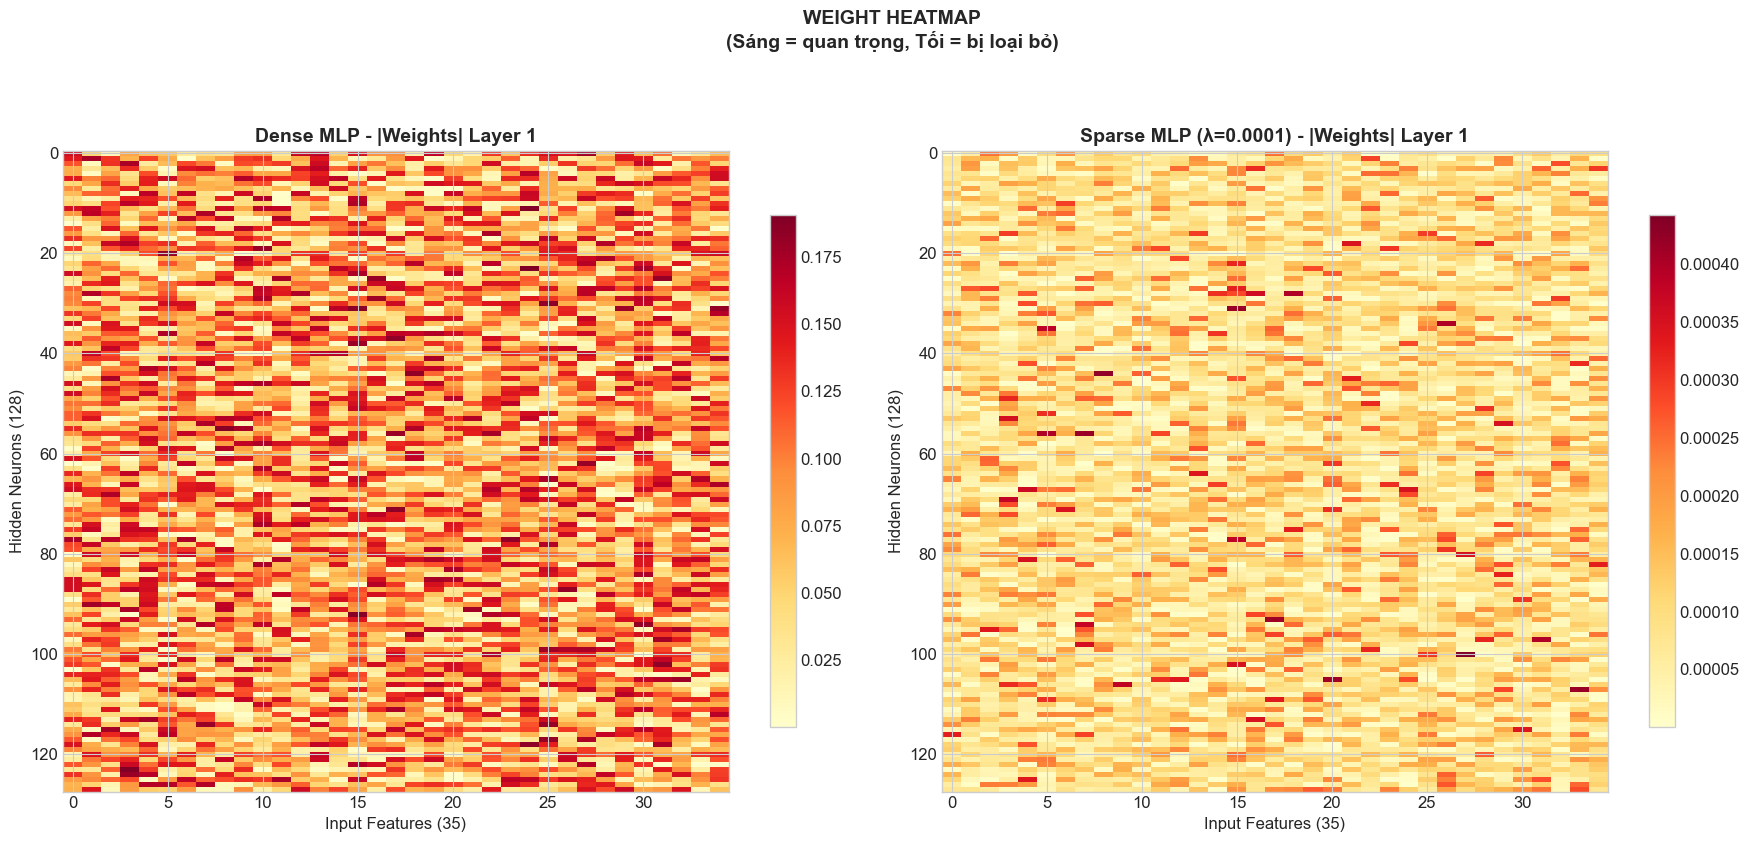

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, w, title in [
    (axes[0], dense_w, 'Dense MLP'),
    (axes[1], sparse_w, f'Sparse MLP (λ={best_lambda})')
]:
    im = ax.imshow(np.abs(w), aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_title(f'{title} - |Weights| Layer 1', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Input Features ({w.shape[1]})')
    ax.set_ylabel(f'Hidden Neurons ({w.shape[0]})')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('WEIGHT HEATMAP\n(Sáng = quan trọng, Tối = bị loại bỏ)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

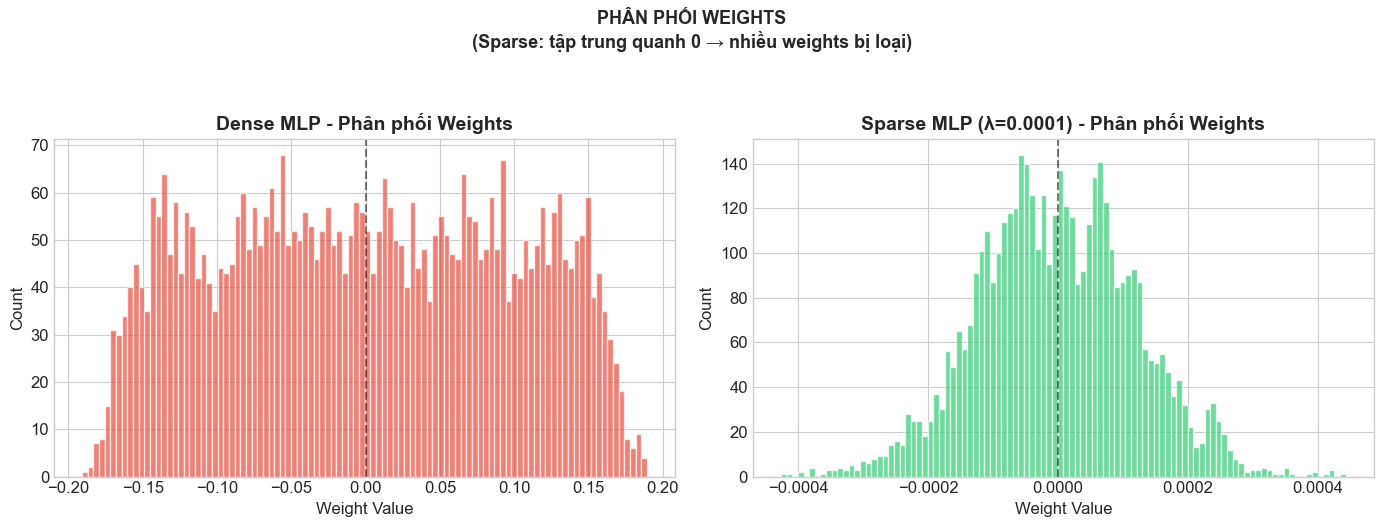

In [23]:
# Phân phối weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w, title, color in [
    (axes[0], dense_w, 'Dense MLP', '#E74C3C'),
    (axes[1], sparse_w, f'Sparse MLP (λ={best_lambda})', '#2ECC71')
]:
    ax.hist(w.flatten(), bins=100, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{title} - Phân phối Weights', fontsize=14, fontweight='bold')
    ax.set_xlabel('Weight Value'); ax.set_ylabel('Count')
    ax.axvline(x=0, color='black', ls='--', alpha=0.5)

plt.suptitle('PHÂN PHỐI WEIGHTS\n(Sparse: tập trung quanh 0 → nhiều weights bị loại)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print("=" * 70)
print("                        TỔNG KẾT")
print("=" * 70)
print(f"""
📊 Dataset:  VN30 - 30 cổ phiếu Việt Nam (2013-2023)
📊 Features: {len(FEATURE_COLS)}
📊 Target:   Forward Return {FORWARD_DAYS} ngày

{'Metric':<18} {'Dense MLP':>12} {'Sparse MLP':>12}
{'─'*45}
{'MSE':<18} {dense_res['mse']:>12.6f} {sparse_res['mse']:>12.6f}
{'RMSE':<18} {dense_res['rmse']:>12.6f} {sparse_res['rmse']:>12.6f}
{'IC':<18} {dense_res['ic']:>12.4f} {sparse_res['ic']:>12.4f}
{'Sparsity':<18} {dense_res['sparsity']:>11.1%} {sparse_res['sparsity']:>11.1%}

🏆 Best λ: {best_lambda}
🔍 Sparse giữ lại: {len(sparse_fi[sparse_fi['importance'] >= 0.01])}/{len(FEATURE_COLS)} features

Top 5 Features (Sparse MLP):""")
for i, row in sparse_fi.head(5).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

print(f"""
📁 Các file đã lưu:
  - target_distribution.png
  - model_comparison.png  
  - feature_importance.png
  - weight_heatmap.png
  - weight_distribution.png
""")




                        TỔNG KẾT

📊 Dataset:  VN30 - 30 cổ phiếu Việt Nam (2013-2023)
📊 Features: 35
📊 Target:   Forward Return 5 ngày

Metric                Dense MLP   Sparse MLP
─────────────────────────────────────────────
MSE                    0.003143     0.003141
RMSE                   0.056059     0.056042
IC                       0.0528          nan
Sparsity                  0.1%       59.5%

🏆 Best λ: 0.0001
🔍 Sparse giữ lại: 35/35 features

Top 5 Features (Sparse MLP):
  1. macd_signal: 0.0139
  2. return_60d: 0.0134
  3. return_20d: 0.0133
  4. return_10d: 0.0133
  5. rsi_7: 0.0132

📁 Các file đã lưu:
  - target_distribution.png
  - model_comparison.png  
  - feature_importance.png
  - weight_heatmap.png
  - weight_distribution.png



## Phần mở rộng — LSTM & Đa phương pháp Interpretability

Theo `IMPROVEMENTS.md`:

- Thêm **LSTM** (Dense + Sparse) → bảng so sánh 2×2 (MLP/LSTM × Dense/Sparse).
- Thêm **SHAP**, **Permutation Importance**, **Integrated Gradients**.
- **Cross-validate** thứ hạng feature giữa các phương pháp bằng Spearman correlation.

In [25]:
# Cài thêm thư viện cho phần mở rộng (chỉ cần chạy 1 lần, sau đó comment lại)
# %pip install -q shap captum

try:
    import shap
    print(f"shap: {shap.__version__}")
except ImportError:
    print("⚠️ Cần cài: pip install shap")

try:
    from captum.attr import IntegratedGradients
    print("captum: ok")
except ImportError:
    print("⚠️ Cần cài: pip install captum")

from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr


shap: 0.51.0
⚠️ Cần cài: pip install captum


### 1. LSTM Models — Capture temporal dependencies

LSTM nhận chuỗi 20 ngày liên tiếp thay vì 1 ngày đơn lẻ. Áp dụng L1 regularization tương tự MLP để tạo sparse version → bảng so sánh 2×2 (MLP/LSTM × Dense/Sparse).

In [26]:
WINDOW = 20

def build_sequences(df_clean, feature_cols, scaler, window=20):
    """Tạo cửa sổ [window, n_features] cho mỗi ngày, gắn với target tại ngày cuối."""
    X_all, y_all, date_all, sym_all = [], [], [], []
    for symbol, g in df_clean.groupby('Symbol'):
        g = g.sort_values('TradingDate').reset_index(drop=True)
        if len(g) < window:
            continue
        X_raw = g[feature_cols].values.astype(float)
        X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
        X_scaled = scaler.transform(X_raw).astype(np.float32)
        y = g['target'].values.astype(np.float32)
        dates = g['TradingDate'].values
        for i in range(window - 1, len(g)):
            X_all.append(X_scaled[i-window+1:i+1])
            y_all.append(y[i])
            date_all.append(dates[i])
            sym_all.append(symbol)
    return (np.stack(X_all),
            np.array(y_all, dtype=np.float32),
            np.array(date_all),
            np.array(sym_all))

X_seq, y_seq, dates_seq, _ = build_sequences(df_clean, FEATURE_COLS, scaler, window=WINDOW)
print(f"X_seq shape: {X_seq.shape}")  # (N, 20, n_features)

dates_pd = pd.Series(dates_seq)
mask_train = dates_pd <= pd.Timestamp(TRAIN_END)
mask_val   = (dates_pd > pd.Timestamp(TRAIN_END)) & (dates_pd <= pd.Timestamp(VAL_END))
mask_test  = dates_pd > pd.Timestamp(VAL_END)

X_train_seq, y_train_seq = X_seq[mask_train], y_seq[mask_train]
X_val_seq,   y_val_seq   = X_seq[mask_val],   y_seq[mask_val]
X_test_seq,  y_test_seq  = X_seq[mask_test],  y_seq[mask_test]

print(f"Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")

X_train_seq_t = torch.FloatTensor(X_train_seq).to(device)
y_train_seq_t = torch.FloatTensor(y_train_seq).reshape(-1, 1).to(device)
X_val_seq_t   = torch.FloatTensor(X_val_seq).to(device)
y_val_seq_t   = torch.FloatTensor(y_val_seq).reshape(-1, 1).to(device)
X_test_seq_t  = torch.FloatTensor(X_test_seq).to(device)
y_test_seq_t  = torch.FloatTensor(y_test_seq).reshape(-1, 1).to(device)

train_loader_seq = DataLoader(
    TensorDataset(X_train_seq_t, y_train_seq_t),
    batch_size=BATCH_SIZE, shuffle=True
)


X_seq shape: (60564, 20, 35)
Train: (41454, 20, 35) | Val: (11490, 20, 35) | Test: (7620, 20, 35)


In [27]:
class SparseLSTM(nn.Module):
    """LSTM cho chuỗi thời gian. Áp dụng L1 trên TẤT CẢ trainable params."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

    def get_l1_loss(self):
        return sum(torch.sum(torch.abs(p)) for p in self.parameters())

    def get_sparsity_ratio(self, threshold=1e-4):
        total = sum(p.numel() for p in self.parameters())
        near_zero = sum((p.abs() < threshold).sum().item() for p in self.parameters())
        return near_zero / total if total > 0 else 0

print(f"SparseLSTM: input_dim={input_dim}, hidden=64, num_layers=2 → 32 → 1")
print(f"Total params: {sum(p.numel() for p in SparseLSTM(input_dim).parameters()):,}")


SparseLSTM: input_dim=35, hidden=64, num_layers=2 → 32 → 1
Total params: 61,249


In [28]:
def train_lstm(model, train_loader, X_val_t, y_val_t,
               epochs=50, lr=1e-3, l1_lambda=0.0,
               patience=8, model_name="LSTM"):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    best_val = float('inf'); best_epoch = 0; best_state = None; no_improve = 0

    print(f"\n{'='*60}\n🚀 {model_name} | L1 λ = {l1_lambda}\n{'='*60}")

    for epoch in range(epochs):
        model.train()
        ep_loss, n = 0.0, 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            mse = criterion(model(X_b), y_b)
            total = mse + l1_lambda * model.get_l1_loss() if l1_lambda > 0 else mse
            total.backward()
            optimizer.step()
            ep_loss += mse.item(); n += 1
        train_losses.append(ep_loss / n)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss; best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            sp = model.get_sparsity_ratio() if l1_lambda > 0 else 0
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_losses[-1]:.6f} | "
                  f"Val: {val_loss:.6f} | Sparsity: {sp:.1%}")
        if no_improve >= patience:
            print(f"  ⏹️ Early stop at epoch {epoch+1} (best: {best_epoch+1})")
            break

    model.load_state_dict(best_state)
    print(f"  Best epoch: {best_epoch+1} | Val MSE: {best_val:.6f}")
    return model, train_losses, val_losses


In [29]:
torch.manual_seed(42)
dense_lstm = SparseLSTM(input_dim).to(device)
dense_lstm, dense_lstm_train, dense_lstm_val = train_lstm(
    dense_lstm, train_loader_seq, X_val_seq_t, y_val_seq_t,
    epochs=40, lr=1e-3, l1_lambda=0.0, patience=8,
    model_name="Dense LSTM (Baseline)"
)



🚀 Dense LSTM (Baseline) | L1 λ = 0.0
  Epoch   1/40 | Train: 0.002378 | Val: 0.003409 | Sparsity: 0.0%
  Epoch   5/40 | Train: 0.002031 | Val: 0.003595 | Sparsity: 0.0%
  ⏹️ Early stop at epoch 9 (best: 1)
  Best epoch: 1 | Val MSE: 0.003409


In [30]:
LSTM_LAMBDAS = [1e-5, 1e-4]  # Search nhỏ vì LSTM training tốn thời gian
lstm_lambda_results = {}

for lam in LSTM_LAMBDAS:
    torch.manual_seed(42)
    m = SparseLSTM(input_dim).to(device)
    m, _, _ = train_lstm(m, train_loader_seq, X_val_seq_t, y_val_seq_t,
                         epochs=40, lr=1e-3, l1_lambda=lam, patience=8,
                         model_name=f"Sparse LSTM (λ={lam})")
    m.eval()
    with torch.no_grad():
        v = nn.MSELoss()(m(X_val_seq_t), y_val_seq_t).item()
    lstm_lambda_results[lam] = {'val_mse': v, 'sparsity': m.get_sparsity_ratio()}
    print(f"  → Val MSE: {v:.6f} | Sparsity: {m.get_sparsity_ratio():.1%}")

best_lambda_lstm = min(lstm_lambda_results, key=lambda k: lstm_lambda_results[k]['val_mse'])
print(f"\n🏆 Best LSTM λ = {best_lambda_lstm}")



🚀 Sparse LSTM (λ=1e-05) | L1 λ = 1e-05
  Epoch   1/40 | Train: 0.002403 | Val: 0.003407 | Sparsity: 41.5%
  Epoch   5/40 | Train: 0.002410 | Val: 0.003400 | Sparsity: 53.1%
  Epoch  10/40 | Train: 0.002410 | Val: 0.003413 | Sparsity: 52.8%
  ⏹️ Early stop at epoch 13 (best: 5)
  Best epoch: 5 | Val MSE: 0.003400
  → Val MSE: 0.003400 | Sparsity: 53.1%

🚀 Sparse LSTM (λ=0.0001) | L1 λ = 0.0001
  Epoch   1/40 | Train: 0.002411 | Val: 0.003407 | Sparsity: 44.7%
  Epoch   5/40 | Train: 0.002409 | Val: 0.003410 | Sparsity: 49.5%
  Epoch  10/40 | Train: 0.002408 | Val: 0.003407 | Sparsity: 49.6%
  Epoch  15/40 | Train: 0.002408 | Val: 0.003406 | Sparsity: 49.3%
  Epoch  20/40 | Train: 0.002408 | Val: 0.003403 | Sparsity: 49.6%
  Epoch  25/40 | Train: 0.002409 | Val: 0.003404 | Sparsity: 49.4%
  Epoch  30/40 | Train: 0.002408 | Val: 0.003408 | Sparsity: 49.8%
  ⏹️ Early stop at epoch 30 (best: 22)
  Best epoch: 22 | Val MSE: 0.003400
  → Val MSE: 0.003400 | Sparsity: 49.9%

🏆 Best LSTM λ = 1

In [31]:
torch.manual_seed(42)
sparse_lstm = SparseLSTM(input_dim).to(device)
sparse_lstm, sparse_lstm_train, sparse_lstm_val = train_lstm(
    sparse_lstm, train_loader_seq, X_val_seq_t, y_val_seq_t,
    epochs=40, lr=1e-3, l1_lambda=best_lambda_lstm, patience=8,
    model_name=f"Sparse LSTM (λ={best_lambda_lstm})"
)



🚀 Sparse LSTM (λ=1e-05) | L1 λ = 1e-05
  Epoch   1/40 | Train: 0.002403 | Val: 0.003407 | Sparsity: 41.5%
  Epoch   5/40 | Train: 0.002410 | Val: 0.003400 | Sparsity: 53.1%
  Epoch  10/40 | Train: 0.002410 | Val: 0.003413 | Sparsity: 52.8%
  ⏹️ Early stop at epoch 13 (best: 5)
  Best epoch: 5 | Val MSE: 0.003400


In [32]:
def evaluate_seq_model(model, X_t, y_np, name="Model"):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_t).cpu().numpy().flatten()
    mse = mean_squared_error(y_np, y_pred)
    rmse = np.sqrt(mse)
    ic = np.corrcoef(y_np, y_pred)[0, 1]
    sparsity = model.get_sparsity_ratio()
    direction_acc = float(np.mean(np.sign(y_pred) == np.sign(y_np)))
    print(f"\n📊 {name}:")
    print(f"  MSE:           {mse:.6f}")
    print(f"  RMSE:          {rmse:.6f}")
    print(f"  IC:            {ic:.4f}")
    print(f"  Sparsity:      {sparsity:.1%}")
    print(f"  Direction Acc: {direction_acc:.4f}")
    return {'name': name, 'mse': mse, 'rmse': rmse, 'ic': ic,
            'sparsity': sparsity, 'direction_acc': direction_acc,
            'y_pred': y_pred, 'y_true': y_np}

# Bổ sung Direction Accuracy cho MLP results
def add_direction_acc(res):
    res['direction_acc'] = float(np.mean(np.sign(res['y_pred']) == np.sign(res['y_true'])))
    return res

dense_res  = add_direction_acc(dense_res)
sparse_res = add_direction_acc(sparse_res)

dense_lstm_res  = evaluate_seq_model(dense_lstm,  X_test_seq_t, y_test_seq, "Dense LSTM")
sparse_lstm_res = evaluate_seq_model(sparse_lstm, X_test_seq_t, y_test_seq, "Sparse LSTM")

# Bảng so sánh 2x2
print("\n" + "=" * 80)
print("              BẢNG SO SÁNH 2×2 (TEST SET)")
print("=" * 80)
print(f"{'Model':<14}{'MSE':>11}{'RMSE':>11}{'IC':>10}{'Sparsity':>11}{'DirAcc':>10}")
print("-" * 80)
for r in [dense_res, sparse_res, dense_lstm_res, sparse_lstm_res]:
    print(f"{r['name']:<14}{r['mse']:>11.6f}{r['rmse']:>11.6f}"
          f"{r['ic']:>10.4f}{r['sparsity']:>11.1%}{r['direction_acc']:>10.4f}")
print("=" * 80)



📊 Dense LSTM:
  MSE:           0.003284
  RMSE:          0.057308
  IC:            0.0441
  Sparsity:      0.1%
  Direction Acc: 0.5073

📊 Sparse LSTM:
  MSE:           0.003140
  RMSE:          0.056038
  IC:            -0.0381
  Sparsity:      53.1%
  Direction Acc: 0.4983

              BẢNG SO SÁNH 2×2 (TEST SET)
Model                 MSE       RMSE        IC   Sparsity    DirAcc
--------------------------------------------------------------------------------
Dense MLP        0.003143   0.056059    0.0528       0.1%    0.5110
Sparse MLP       0.003141   0.056042       nan      59.5%    0.4983
Dense LSTM       0.003284   0.057308    0.0441       0.1%    0.5073
Sparse LSTM      0.003140   0.056038   -0.0381      53.1%    0.4983


### 2. SHAP Analysis (DeepExplainer)

So sánh phân bố SHAP giữa Dense vs Sparse MLP:
- Dense → SHAP phân tán nhiều features → khó giải thích.
- Sparse → SHAP tập trung ít features → dễ giải thích hơn.

In [33]:
np.random.seed(42)
N_BG, N_TEST = 200, 500
bg_idx   = np.random.choice(len(X_train), N_BG, replace=False)
test_idx = np.random.choice(len(X_test), N_TEST, replace=False)

bg_t          = torch.FloatTensor(X_train[bg_idx]).to(device)
test_subset_t = torch.FloatTensor(X_test[test_idx]).to(device)

def compute_shap(model, bg, X_explain):
    model.eval()
    try:
        explainer = shap.DeepExplainer(model, bg)
        sv = explainer.shap_values(X_explain, check_additivity=False)
    except Exception as e:
        print(f"  DeepExplainer fallback → GradientExplainer (lỗi: {e})")
        explainer = shap.GradientExplainer(model, bg)
        sv = explainer.shap_values(X_explain)
    if isinstance(sv, list):
        sv = sv[0]
    return np.asarray(sv).reshape(X_explain.shape[0], -1)

print("Tính SHAP cho Dense MLP...")
shap_dense = compute_shap(dense_model, bg_t, test_subset_t)
print(f"  shape: {shap_dense.shape}")

print("Tính SHAP cho Sparse MLP...")
shap_sparse = compute_shap(sparse_model, bg_t, test_subset_t)
print(f"  shape: {shap_sparse.shape}")

shap_dense_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'shap_mean_abs': np.mean(np.abs(shap_dense), axis=0)
}).sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)

shap_sparse_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'shap_mean_abs': np.mean(np.abs(shap_sparse), axis=0)
}).sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)

print("\nTop 10 features (Sparse — SHAP):")
for i, r in shap_sparse_imp.head(10).iterrows():
    print(f"  {i+1:2d}. {r['feature']:<22s} | {r['shap_mean_abs']:.5f}")


Tính SHAP cho Dense MLP...
  shape: (500, 35)
Tính SHAP cho Sparse MLP...
  shape: (500, 35)

Top 10 features (Sparse — SHAP):
   1. bb_width               | 0.00000
   2. std_ratio              | 0.00000
   3. stoch_k                | 0.00000
   4. stoch_d                | 0.00000
   5. roc_10                 | 0.00000
   6. bb_pct_b               | 0.00000
   7. return_20d             | 0.00000
   8. obv_norm               | 0.00000
   9. vol_ratio_5_20         | 0.00000
  10. willr_14               | 0.00000


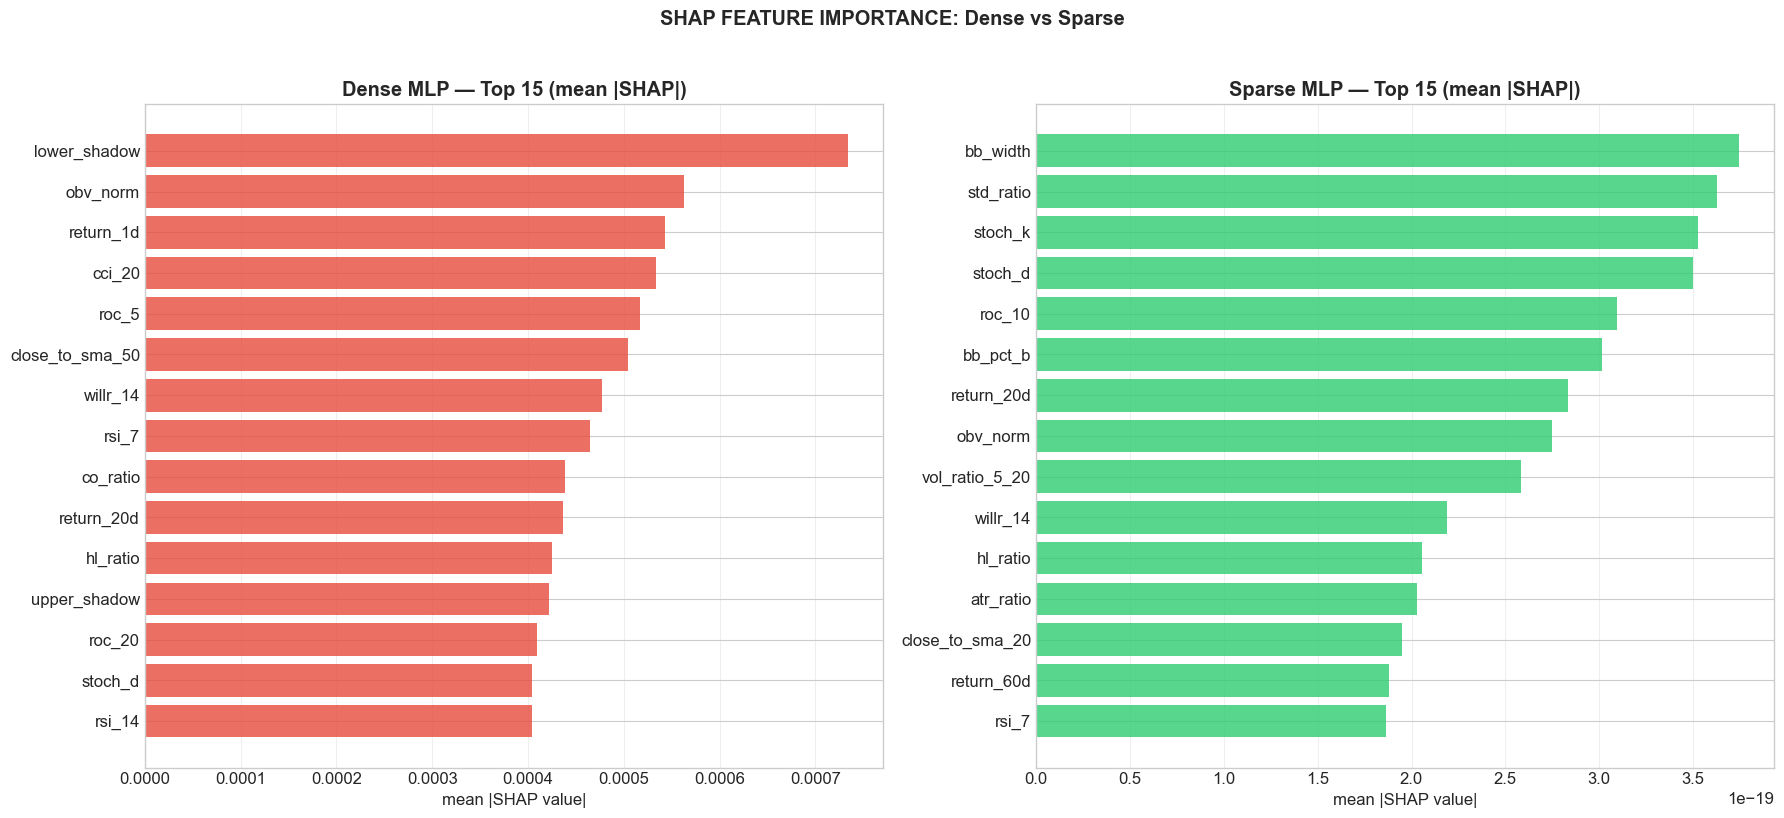


Tỉ lệ |SHAP| tập trung vào top-5 features:
  Dense:  22.6%
  Sparse: 28.6%  (cao hơn → giải thích tập trung hơn)


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_n = 15
for ax, imp, title, color in [
    (axes[0], shap_dense_imp.head(top_n),  'Dense MLP',  '#E74C3C'),
    (axes[1], shap_sparse_imp.head(top_n), 'Sparse MLP', '#2ECC71'),
]:
    ax.barh(range(len(imp)), imp['shap_mean_abs'].values, color=color, alpha=0.8)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp['feature'].values)
    ax.invert_yaxis()
    ax.set_title(f'{title} — Top {top_n} (mean |SHAP|)', fontweight='bold')
    ax.set_xlabel('mean |SHAP value|')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle('SHAP FEATURE IMPORTANCE: Dense vs Sparse', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Concentration check: % importance trong top-5 features
def conc(imp, k=5):
    total = imp['shap_mean_abs'].sum()
    return float(imp['shap_mean_abs'].head(k).sum() / total) if total > 0 else 0

print(f"\nTỉ lệ |SHAP| tập trung vào top-5 features:")
print(f"  Dense:  {conc(shap_dense_imp):.1%}")
print(f"  Sparse: {conc(shap_sparse_imp):.1%}  (cao hơn → giải thích tập trung hơn)")


### 3. Permutation Feature Importance

Shuffle giá trị 1 feature → đo MSE tăng → feature càng quan trọng càng làm tăng MSE nhiều.

In [35]:
class TorchModelWrapper:
    """Wrapper để sklearn permutation_importance gọi được PyTorch model."""
    _estimator_type = "regressor"
    def __init__(self, model, device='cpu'):
        self.model = model
        self.device = device
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.FloatTensor(np.asarray(X, dtype=np.float32)).to(self.device)
            return self.model(t).cpu().numpy().flatten()
    def score(self, X, y):
        return -mean_squared_error(y, self.predict(X))

def perm_importance(model, X, y, feature_names, n_repeats=5, sample=2000):
    if len(X) > sample:
        idx = np.random.choice(len(X), sample, replace=False)
        X, y = X[idx], y[idx]
    wrapper = TorchModelWrapper(model, device=device)
    res = permutation_importance(wrapper, X, y, n_repeats=n_repeats, random_state=42, n_jobs=1)
    return pd.DataFrame({
        'feature': feature_names,
        'perm_importance': res.importances_mean,
        'perm_std': res.importances_std,
    }).sort_values('perm_importance', ascending=False).reset_index(drop=True)

np.random.seed(42)
print("Tính Permutation Importance cho Dense MLP...")
perm_dense_imp = perm_importance(dense_model, X_test, y_test, FEATURE_COLS)
print("Tính Permutation Importance cho Sparse MLP...")
perm_sparse_imp = perm_importance(sparse_model, X_test, y_test, FEATURE_COLS)

print("\nTop 10 features (Sparse — Permutation):")
for i, r in perm_sparse_imp.head(10).iterrows():
    print(f"  {i+1:2d}. {r['feature']:<22s} | {r['perm_importance']:.5f}")


Tính Permutation Importance cho Dense MLP...
Tính Permutation Importance cho Sparse MLP...

Top 10 features (Sparse — Permutation):
   1. return_1d              | 0.00000
   2. vol_ratio_5_20         | 0.00000
   3. willr_14               | 0.00000
   4. cci_20                 | 0.00000
   5. atr_ratio              | 0.00000
   6. bb_pct_b               | 0.00000
   7. bb_width               | 0.00000
   8. std_ratio              | 0.00000
   9. vol_change_1d          | 0.00000
  10. stoch_k                | 0.00000


### 4. Integrated Gradients (Captum) — Optional

Phương pháp gradient-based gốc Captum, có cơ sở lý thuyết axiom-based, chuyên cho neural networks.

In [36]:
ig_dense  = IntegratedGradients(dense_model)
ig_sparse = IntegratedGradients(sparse_model)

baseline = torch.zeros_like(test_subset_t)
attr_dense  = ig_dense.attribute(test_subset_t,  baselines=baseline, n_steps=50).detach().cpu().numpy()
attr_sparse = ig_sparse.attribute(test_subset_t, baselines=baseline, n_steps=50).detach().cpu().numpy()

ig_dense_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'ig_mean_abs': np.mean(np.abs(attr_dense), axis=0),
}).sort_values('ig_mean_abs', ascending=False).reset_index(drop=True)

ig_sparse_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'ig_mean_abs': np.mean(np.abs(attr_sparse), axis=0),
}).sort_values('ig_mean_abs', ascending=False).reset_index(drop=True)

print("Top 10 features (Sparse — Integrated Gradients):")
for i, r in ig_sparse_imp.head(10).iterrows():
    print(f"  {i+1:2d}. {r['feature']:<22s} | {r['ig_mean_abs']:.5f}")


NameError: name 'IntegratedGradients' is not defined

### 5. Cross-validate Ranking — Spearman correlation

Nếu cả 4 phương pháp (Weight, SHAP, Permutation, Integrated Gradients) cho ranking tương tự (ρ cao) → kết quả interpretability đáng tin cậy.

In [ ]:
# Lấy ranking theo từng phương pháp, theo thứ tự FEATURE_COLS
def to_rank(df, val_col):
    s = df.set_index('feature')[val_col]
    return s.reindex(FEATURE_COLS).rank(ascending=False).values

weight_rank_sp = to_rank(sparse_fi, 'importance')
shap_rank_sp   = to_rank(shap_sparse_imp, 'shap_mean_abs')
perm_rank_sp   = to_rank(perm_sparse_imp, 'perm_importance')
ig_rank_sp     = to_rank(ig_sparse_imp, 'ig_mean_abs')

methods = {
    'Weight': weight_rank_sp,
    'SHAP':   shap_rank_sp,
    'Perm':   perm_rank_sp,
    'IG':     ig_rank_sp,
}
names = list(methods.keys())
corr_mat = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        rho, _ = spearmanr(methods[a], methods[b])
        corr_mat[i, j] = rho

print("\nSpearman ρ giữa các phương pháp (Sparse MLP):")
print(f"{'':<8}" + ''.join(f"{n:>10}" for n in names))
for i, n in enumerate(names):
    print(f"{n:<8}" + ''.join(f"{corr_mat[i,j]:>10.3f}" for j in range(len(names))))

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_mat, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{corr_mat[i,j]:.2f}",
                ha='center', va='center',
                color='black' if abs(corr_mat[i,j]) < 0.6 else 'white',
                fontsize=11)
ax.set_title('Spearman ρ (Sparse MLP) — 4 phương pháp interpretability', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('interpretability_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Lưu LSTM models + extended interpretability artifacts
torch.save(dense_lstm.state_dict(), 'dense_lstm.pth')
torch.save(sparse_lstm.state_dict(), 'sparse_lstm.pth')

extended = {
    'window': WINDOW,
    'best_lambda_lstm': best_lambda_lstm,
    'dense_lstm_res':  {k: v for k, v in dense_lstm_res.items()  if k not in ('y_pred', 'y_true')},
    'sparse_lstm_res': {k: v for k, v in sparse_lstm_res.items() if k not in ('y_pred', 'y_true')},
    'shap_dense_imp':  shap_dense_imp,
    'shap_sparse_imp': shap_sparse_imp,
    'perm_dense_imp':  perm_dense_imp,
    'perm_sparse_imp': perm_sparse_imp,
    'ig_dense_imp':    ig_dense_imp,
    'ig_sparse_imp':   ig_sparse_imp,
    'spearman_methods': names,
    'spearman_corr':    corr_mat,
}

with open('model_metadata_extended.pkl', 'wb') as f:
    pickle.dump(extended, f)

print("✅ Đã lưu:")
print("  - dense_lstm.pth")
print("  - sparse_lstm.pth")
print("  - model_metadata_extended.pkl")
print("  - shap_importance.png")
print("  - interpretability_correlation.png")


In [ ]:
# %%
# SAVE MODEL & SCALER cho Web App
import pickle

# Lưu models
torch.save(dense_model.state_dict(), 'dense_model.pth')
torch.save(sparse_model.state_dict(), 'sparse_model.pth')

# Lưu scaler + metadata
metadata = {
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'input_dim': input_dim,
    'best_lambda': best_lambda,
    'dense_res': {k: v for k, v in dense_res.items() if k != 'y_pred' and k != 'y_true'},
    'sparse_res': {k: v for k, v in sparse_res.items() if k != 'y_pred' and k != 'y_true'},
    'dense_fi': dense_fi,
    'sparse_fi': sparse_fi,
    'dense_w': dense_w,
    'sparse_w': sparse_w,
    'vn30_symbols': VN30_SYMBOLS,
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✅ Đã lưu:")
print("  - dense_model.pth")
print("  - sparse_model.pth")  
print("  - model_metadata.pkl")

✅ Đã lưu:
  - dense_model.pth
  - sparse_model.pth
  - model_metadata.pkl
